In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# allow imports from src/
ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(ROOT / "src"))

from compare.plots import (
    plot_lines, plot_sweep, plot_far_recall, plot_eer,
    plot_auc_auprc, plot_precision_recall_bar, plot_f1,
    plot_eer_by_dim, plot_eer_train_n_by_dim,
)

In [2]:
df = pd.read_parquet(ROOT / "results" / "sweep.parquet")
df.head()

,p_trial,p_embedding_dim,p_adapter,p_train_n,p_epochs,p_device,p_input_dim,m_recall,m_precision,m_f1,m_false_alarm_rate,m_accuracy,m_auc,m_auprc,m_eer,m_threshold,p_n_components,p_covariance_type,p_k
0,0,32,AutoencoderAdapter,10,100.0,mps,32.0,0.985185,0.558042,0.712500,0.754177,0.609223,0.954990,0.963845,0.111641,0.695527,NaN,NaN,NaN
1,0,32,AutoencoderAdapter,15,100.0,mps,32.0,0.935802,0.845982,0.888628,0.164678,0.884709,0.961655,0.969768,0.091025,1.728876,NaN,NaN,NaN
2,0,32,AutoencoderAdapter,20,100.0,mps,32.0,0.839506,0.991254,0.909091,0.007160,0.917476,0.970842,0.977431,0.065553,2.562416,NaN,NaN,NaN
3,0,32,AutoencoderAdapter,25,100.0,mps,32.0,0.940741,0.927007,0.933824,0.071599,0.934466,0.977719,0.983194,0.066664,1.776408,NaN,NaN,NaN
4,0,32,AutoencoderAdapter,30,100.0,mps,32.0,0.967901,0.814969,0.884876,0.212411,0.876214,0.974778,0.980958,0.060697,1.397520,NaN,NaN,NaN


## 1. Autoencoder (16 vs 32)

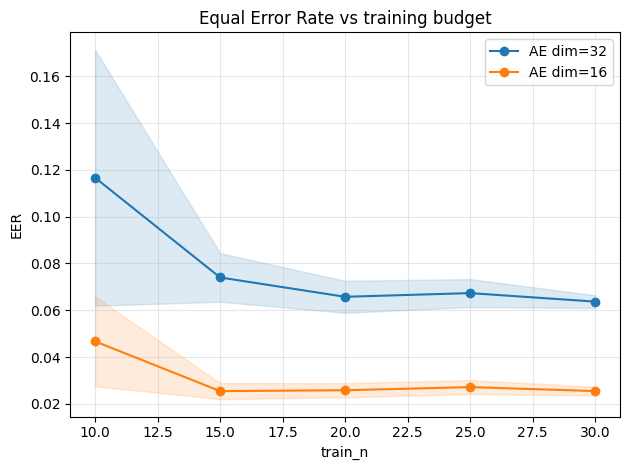

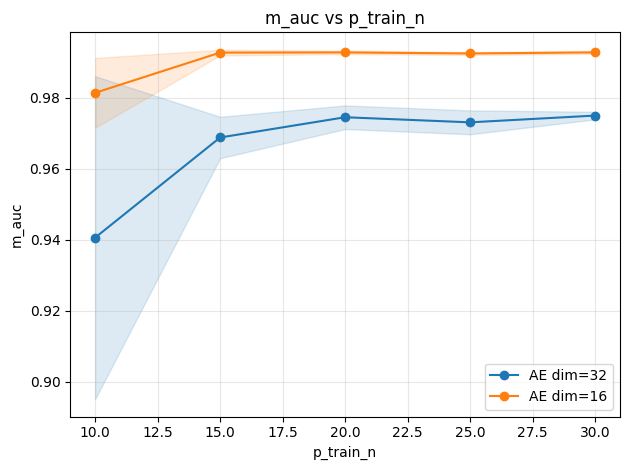

In [3]:
ae_lines = [
    ("AE dim=32", {"p_adapter": "AutoencoderAdapter", "p_embedding_dim": 32}),
    ("AE dim=16", {"p_adapter": "AutoencoderAdapter", "p_embedding_dim": 16}),
]
plot_eer(df, lines=ae_lines)
plot_lines(df, x="p_train_n", y="m_auc", lines=ae_lines)

## 2. GMM (n_components × covariance_type × dim)

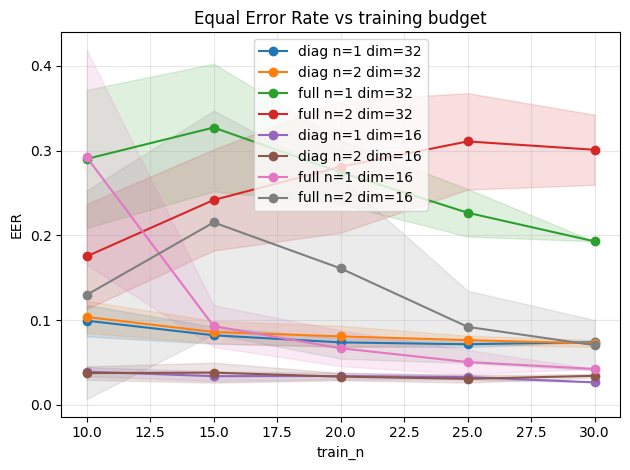

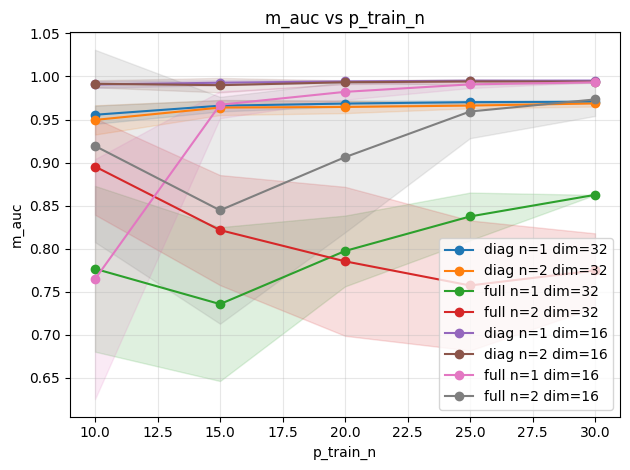

In [4]:
gmm_lines = [
    ("diag n=1 dim=32", {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "diag", "p_embedding_dim": 32}),
    ("diag n=2 dim=32", {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "diag", "p_embedding_dim": 32}),
    ("full n=1 dim=32", {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "full", "p_embedding_dim": 32}),
    ("full n=2 dim=32", {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "full", "p_embedding_dim": 32}),
    ("diag n=1 dim=16", {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "diag", "p_embedding_dim": 16}),
    ("diag n=2 dim=16", {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "diag", "p_embedding_dim": 16}),
    ("full n=1 dim=16", {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "full", "p_embedding_dim": 16}),
    ("full n=2 dim=16", {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "full", "p_embedding_dim": 16}),
]
plot_eer(df, lines=gmm_lines)
plot_lines(df, x="p_train_n", y="m_auc", lines=gmm_lines)

## 2b. GMM threshold percentile sweep (diag, n=1,2, dim=16,32)

In [ ]:
gmm_thresh = df[df["p_adapter"] == "GMMAdapter"].copy()

# F1 vs threshold_percentile — one line per (n_components, dim) combo
thresh_lines = [
    ("n=1 dim=16", {"p_n_components": 1, "p_covariance_type": "diag", "p_embedding_dim": 16}),
    ("n=2 dim=16", {"p_n_components": 2, "p_covariance_type": "diag", "p_embedding_dim": 16}),
    ("n=1 dim=32", {"p_n_components": 1, "p_covariance_type": "diag", "p_embedding_dim": 32}),
    ("n=2 dim=32", {"p_n_components": 2, "p_covariance_type": "diag", "p_embedding_dim": 32}),
]

plot_lines(gmm_thresh, x="p_threshold_percentile", y="m_f1", lines=thresh_lines)
plot_lines(gmm_thresh, x="p_threshold_percentile", y="m_false_alarm_rate", lines=thresh_lines)
plot_lines(gmm_thresh, x="p_threshold_percentile", y="m_recall", lines=thresh_lines)
plot_lines(gmm_thresh, x="p_threshold_percentile", y="m_precision", lines=thresh_lines)

## 3. KNN (k × dim)

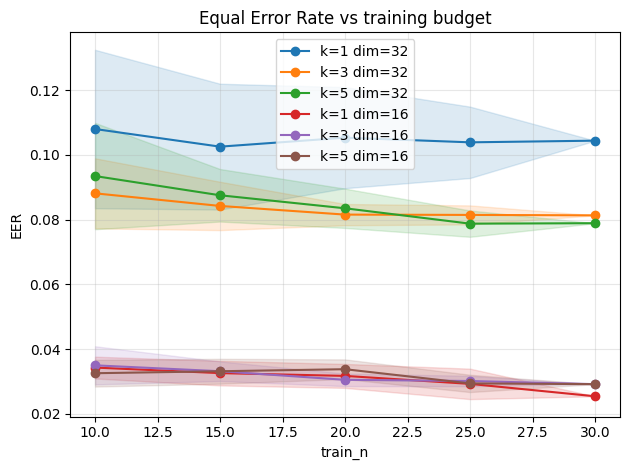

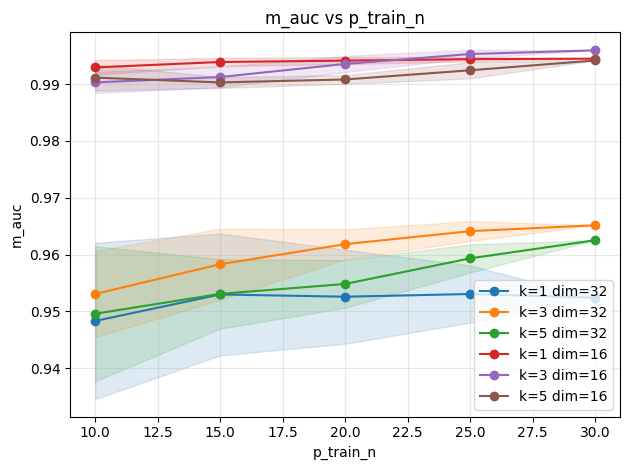

In [5]:
knn_lines = [
    ("k=1 dim=32", {"p_adapter": "KNNAdapter", "p_k": 1, "p_embedding_dim": 32}),
    ("k=3 dim=32", {"p_adapter": "KNNAdapter", "p_k": 3, "p_embedding_dim": 32}),
    ("k=5 dim=32", {"p_adapter": "KNNAdapter", "p_k": 5, "p_embedding_dim": 32}),
    ("k=1 dim=16", {"p_adapter": "KNNAdapter", "p_k": 1, "p_embedding_dim": 16}),
    ("k=3 dim=16", {"p_adapter": "KNNAdapter", "p_k": 3, "p_embedding_dim": 16}),
    ("k=5 dim=16", {"p_adapter": "KNNAdapter", "p_k": 5, "p_embedding_dim": 16}),
]
plot_eer(df, lines=knn_lines)
plot_lines(df, x="p_train_n", y="m_auc", lines=knn_lines)

## 4. Final comparison (dim=16)

In [6]:
final_lines = [
    ("AE",           {"p_adapter": "AutoencoderAdapter", "p_embedding_dim": 16}),
    ("GMM diag n=1", {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "diag", "p_embedding_dim": 16}),
    ("GMM diag n=2", {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "diag", "p_embedding_dim": 16}),
    ("KNN k=1",      {"p_adapter": "KNNAdapter", "p_k": 1, "p_embedding_dim": 16}),
    ("KNN k=3",      {"p_adapter": "KNNAdapter", "p_k": 3, "p_embedding_dim": 16}),
    ("KNN k=5",      {"p_adapter": "KNNAdapter", "p_k": 5, "p_embedding_dim": 16}),
]

In [13]:
# Summary table: mean metrics per adapter config at dim=16
dim16 = df[df["p_embedding_dim"] == 16].copy()
# Build a label column from non-NaN params
dim16["config"] = dim16["p_adapter"]
for col in ["p_n_components", "p_covariance_type", "p_k"]:
    mask = dim16[col].notna()
    dim16.loc[mask, "config"] += " " + col.removeprefix("p_") + "=" + dim16.loc[mask, col].astype(str)

summary = (
    dim16
    .groupby(["config", "p_train_n"])
    [["m_eer", "m_auc", "m_f1", "m_precision", "m_recall", "m_false_alarm_rate"]]
    .mean()
    .round(4)
)
print(summary)

                                                             m_eer   m_auc  \
config                                           p_train_n                   
AutoencoderAdapter                               10         0.0467  0.9813   
                                                 15         0.0255  0.9927   
                                                 20         0.0258  0.9927   
                                                 25         0.0272  0.9924   
                                                 30         0.0255  0.9927   
GMMAdapter n_components=1.0 covariance_type=diag 10         0.0392  0.9907   
                                                 15         0.0340  0.9928   
                                                 20         0.0341  0.9942   
                                                 25         0.0328  0.9951   
                                                 30         0.0266  0.9953   
GMMAdapter n_components=1.0 covariance_type=full 10         0.29

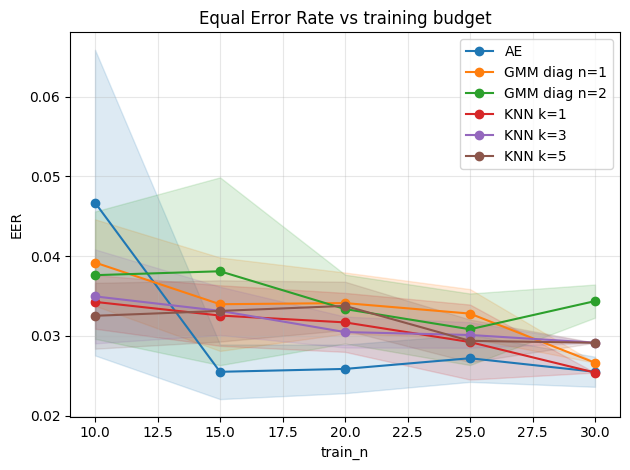

In [8]:
plot_eer(df, lines=final_lines)

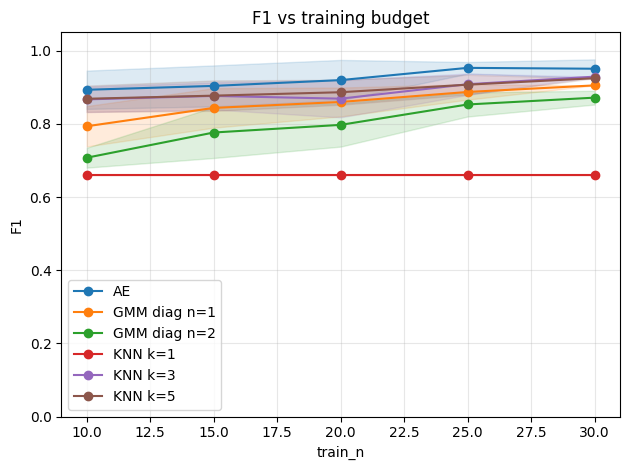

In [9]:
plot_f1(df, lines=final_lines)

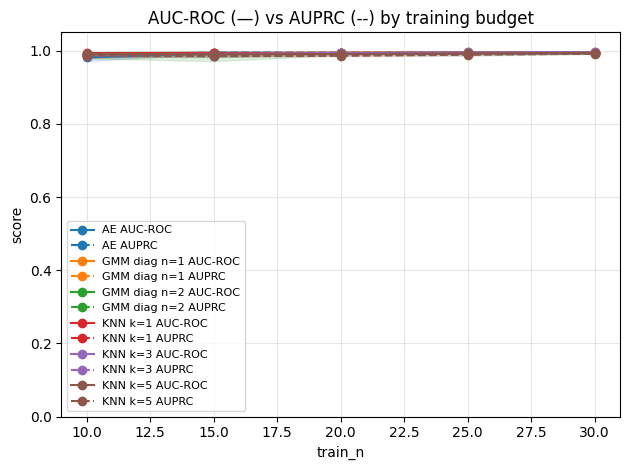

In [10]:
plot_auc_auprc(df, lines=final_lines)

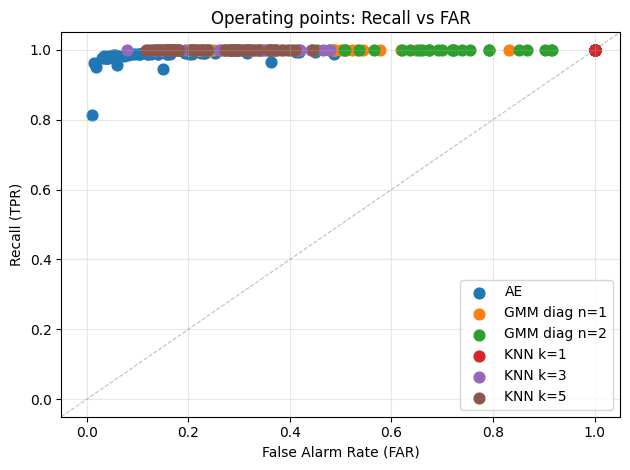

In [11]:
plot_far_recall(df, lines=final_lines)

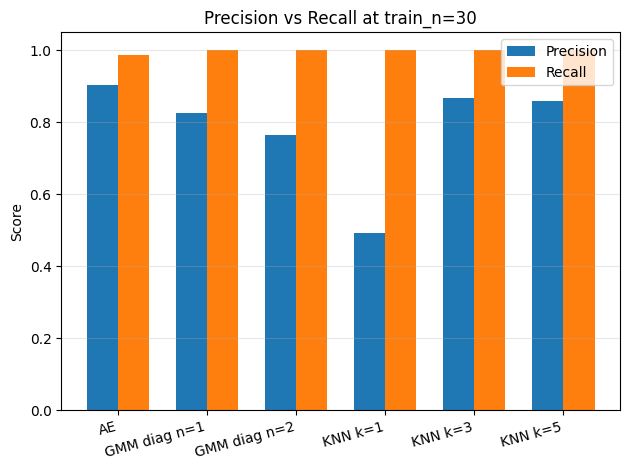

In [12]:
plot_precision_recall_bar(df, train_n=30, lines=final_lines)